In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")
df.head()


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [3]:
df.shape

(5000, 13)

In [4]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [5]:
df.duplicated().sum()


2

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


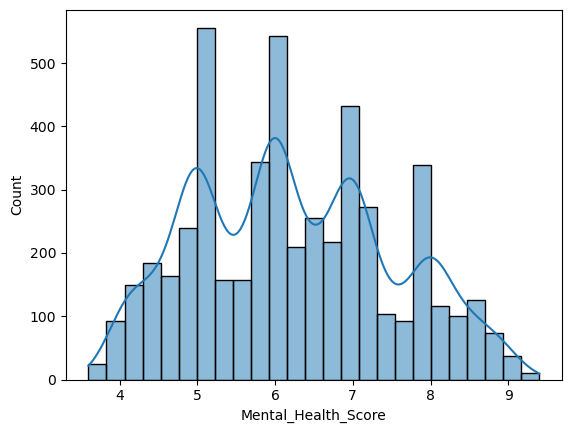

In [8]:
# EDA:

sns.histplot(df['Mental_Health_Score'],kde=True)
plt.show()

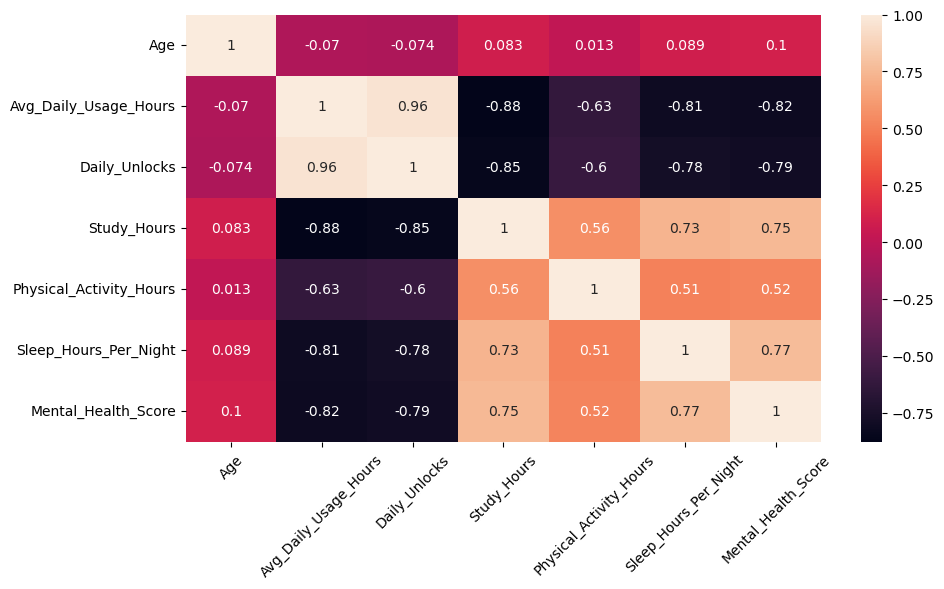

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

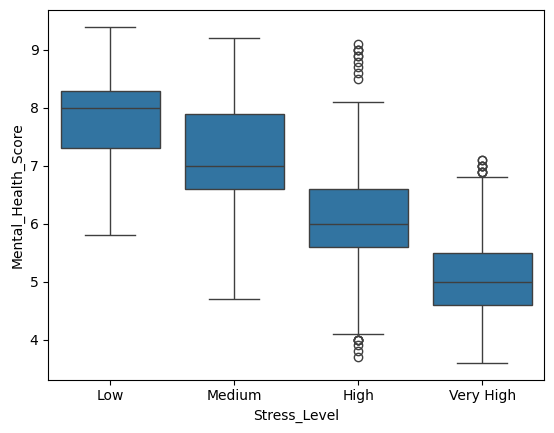

In [11]:
order = ['Low','Medium', 'High','Very High']
sns.boxplot(x='Stress_Level',y = 'Mental_Health_Score',data=df,order=order)
plt.show()


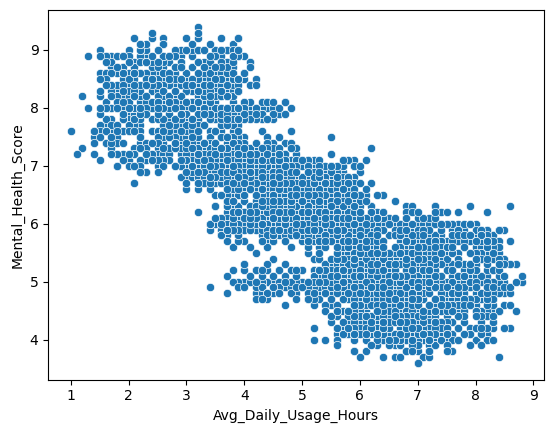

In [12]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)
plt.show()

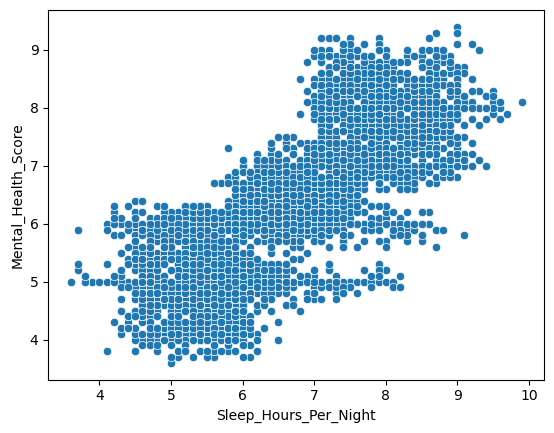

In [13]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)
plt.show()

In [14]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [15]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

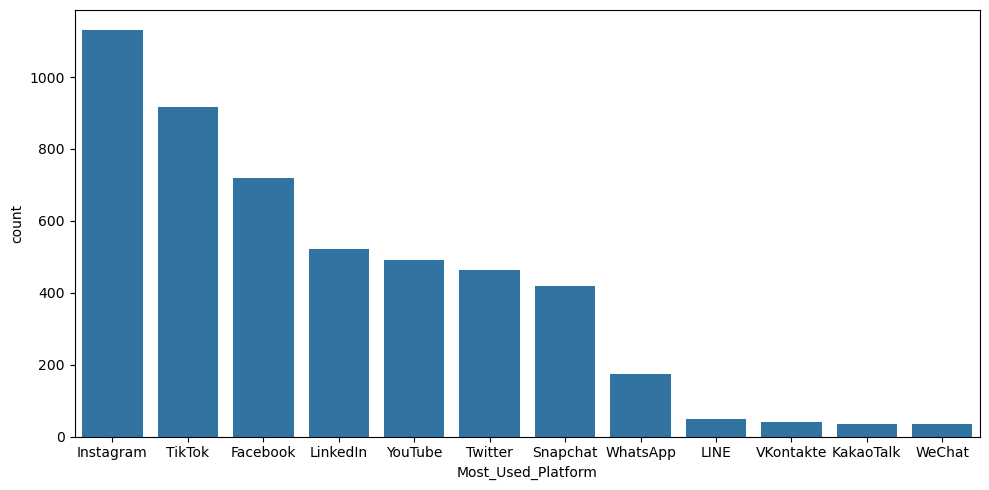

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)
plt.tight_layout()
plt.show()

In [17]:
# Checking outliers:

numeric_features = df.select_dtypes(include='number')

Q1= numeric_features.quantile(0.25)
Q3= numeric_features.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (numeric_features<lower_bound) | (numeric_features>upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [18]:
#  Data Cleaning:

df = df.drop_duplicates()

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [19]:
# checking skewness :

numeric_col = df.select_dtypes(include='number')

numeric_col.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [20]:
# Feature Engineering:

top_countries = df['Country'].value_counts().index[:10].to_list()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Turkey',
 'Mexico',
 'France']

In [21]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [22]:
df['Grouped_country'] = df['Country'].apply(group_countries)
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [23]:
# Train test split:

from sklearn.model_selection import train_test_split

skewed_col = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                    "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]


feature_col = skewed_col + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [24]:
# preprocessing:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer , StandardScaler , OrdinalEncoder , OneHotEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps=[('log_transform',FunctionTransformer(np.log1p)),('scaler',StandardScaler())])

plain_numeric_pipeline = Pipeline(steps=[('scale',StandardScaler())])

ordinal_pipeline = Pipeline(steps=[('encode',OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))])

nominal_pipeline = Pipeline(steps=[('encode',OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skewed_col),
    ("Plain_Numeric",plain_numeric_pipeline, other_numeric_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', nominal_pipeline, normal_col)
])
preprocessor


ColumnTransformer(transformers=[('Skewed_Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Plain_Numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Normal',
                                 Pipeline(steps=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Grouped_country'])])

In [25]:
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

lr_pipeline = Pipeline(steps=[('preprocessor',preprocessor),('regressor',LinearRegression())])
lr_pipeline.fit(X_train,y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')
     

Accuracy of Training 0.7019953304263022
Accuracy of Testing 0.7224910944698808
MAE 0.5576294270833334


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")
     

Accuracy of Training 0.9808287942404612
Accuracy of Testing 0.8775888638668996
MAE : 0.34722113333333343


In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators' : [100,200,300],
    'random forest__max_depth' : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'P...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [28]:

random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [29]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8650140569761653
MAE Score for random forest after hyperparameter tuning 0.3689015766630922


In [30]:
# Model evaluation:

from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.722491     0.701995  0.557629  0.698148
1  Random Forest (default)  0.877589     0.980829  0.347221  0.463681
2    Random Forest (tuned)  0.865014     0.954703  0.368902  0.486915


In [31]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')
     

['Mental_Health_Model.pkl']